# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

... подгружается по мере необходимости ..

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

path = 'data/datasets/'
tracks = pd.read_parquet(path + 'tracks.parquet')
catalog = pd.read_parquet(path + 'catalog_names.parquet')
interactions = pd.read_parquet(path + 'interactions.parquet')

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

### Данных о треках

In [64]:
# общий обзор (и пустые значения)
display(tracks)
display(tracks.info())

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]
...,...,...,...,...
999995,101478482,[21399811],[5540395],"[3, 75]"
999996,101490148,[21403052],[9078726],"[11, 20]"
999997,101493057,[21403883],[11865715],"[44, 75]"
999998,101495927,[21404975],[4462686],"[3, 75]"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


None

In [ ]:
# проверка на дубликаты (необходимо преобразовать массивы в tuples для возможности хеширования)
pd.concat([
        tracks['track_id'], 
        tracks['albums'].apply(tuple),
        tracks['artists'].apply(tuple),
        tracks['genres'].apply(tuple)
    ], axis=1).duplicated().sum()

0

### Данных каталога

In [66]:
# общий обзор (и пустые значения)
display(catalog)
display(catalog.info(show_counts=True))

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack
...,...,...,...
1812466,101478482,track,На лицо
1812467,101490148,track,Без капли мысли
1812468,101493057,track,SKITTLES
1812469,101495927,track,Москва


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   id      1812471 non-null  int64 
 1   type    1812471 non-null  object
 2   name    1812471 non-null  object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


None

In [ ]:
# проверка на дубликаты
catalog.duplicated().sum()

0

In [35]:
catalog.type.unique()

array(['album', 'artist', 'genre', 'track'], dtype=object)

In [73]:
display('album', catalog.query('type == "album"'))
display('artist', catalog.query('type == "artist"'))
display('artist', catalog.query('type == "artist"'))
display('track', catalog.query('type == "track"'))

'album'

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack
...,...,...,...
658719,21458141,album,The Lazy Singles
658720,21458207,album,Jackie Mittoo Anthology
658721,21458968,album,Master Composers: Johann Sebastian Bach
658722,21459622,album,Take the Money and Run


'artist'

,id,type,name
658724,4,artist,Kenny Dorham
658725,5,artist,Max Roach
658726,7,artist,Francis Rossi
658727,9,artist,Status Quo
658728,12,artist,Phil Everly
...,...,...,...
812300,16093680,artist,Los Tiburones
812301,16097398,artist,AMELI
812302,16098445,artist,2GANGSTA
812303,16099125,artist,Daria


'artist'

,id,type,name
658724,4,artist,Kenny Dorham
658725,5,artist,Max Roach
658726,7,artist,Francis Rossi
658727,9,artist,Status Quo
658728,12,artist,Phil Everly
...,...,...,...
812300,16093680,artist,Los Tiburones
812301,16097398,artist,AMELI
812302,16098445,artist,2GANGSTA
812303,16099125,artist,Daria


'track'

,id,type,name
812471,26,track,Complimentary Me
812472,38,track,Momma's Boy
812473,135,track,Atticus
812474,136,track,24 Hours
812475,138,track,Don't Upset The Rhythm (Go Baby Go)
...,...,...,...
1812466,101478482,track,На лицо
1812467,101490148,track,Без капли мысли
1812468,101493057,track,SKITTLES
1812469,101495927,track,Москва


### Данных взаимодействий

In [77]:
# общий обзор (и пустые значения)
display(interactions)
display(interactions.info(show_counts=True))

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22
...,...,...,...,...
287,1374582,95514767,288,2022-12-29
288,1374582,97220301,289,2022-12-29
289,1374582,97241171,290,2022-12-29
290,1374582,98542641,291,2022-12-29


<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Non-Null Count      Dtype         
---  ------      --------------      -----         
 0   user_id     222629898 non-null  int32         
 1   track_id    222629898 non-null  int32         
 2   track_seq   222629898 non-null  int16         
 3   started_at  222629898 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


None

In [ ]:
# почему индекс всего до 291 ?
display(interactions.index[:30])
display(interactions.head(30))

# понятно - сборная куча историй по каждому пользователю, без переиндексации финального датасета

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25,  0,  1,  2,  3],
      dtype='int64')

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22
5,0,590803,6,2022-07-25
6,0,597196,7,2022-07-25
7,0,597199,8,2022-07-25
8,0,1750835,9,2022-07-30
9,0,1750843,10,2022-08-05


In [ ]:
# проверим за какой диапазон дат есть история, и нет ли выбросов

interactions.started_at.min(), interactions.started_at.max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2022-12-31 00:00:00'))

### Проверка - есть ли треки с неизвестными исполнителями, альбомами, жанрами

#### Проверяем сначала треки, у которых не указаны связанные сущности

Треки, у которых нет альбомов - проверим просто для интереса, но в целом тут нет какой-то проблемы, что трек не добавлен в альбом

In [ ]:
# проверка записей, у которых не заданы связанные сущности

track_empty_albums = tracks[tracks['albums'].apply(len) == 0]
print(f'tracks with empty albums = {track_empty_albums.shape[0]}')

# 18 треков без альбомов - очень мало, значит почти каждый трек есть в каком-то альбоме .. ну ок

tracks with empty albums = 18


Треки, у которых нет исполнителя или жанра - это проблема или ошибка в данных - эти треки надо будет исключить

In [ ]:
# проверка записей, у которых не заданы связанные сущности

track_empty_arists = tracks[tracks['artists'].apply(len) == 0]
track_empty_genres = tracks[tracks['genres'].apply(len) == 0]

print(f'tracks with empty arists = {track_empty_arists.shape[0]}')
print(f'tracks with empty genres = {track_empty_genres.shape[0]}')
print(f'total number of track with empty items = {track_empty_arists.shape[0] + track_empty_genres.shape[0]}')

# Проблемные треки:
#   - tracks with empty arists = 15369
#   - tracks with empty genres = 3687
#   - total number of track with emptыy items = 19056

tracks with empty arists = 15369
tracks with empty genres = 3687
total number of track with empty items = 19056


#### Проверяем треки, у которых установлены ссылки на объекты, которых не существуюет

In [42]:
# сформируем плоское представление записей, чтобы проверить корректность ссылок на связанные объекты
tracks_flat = tracks \
    .explode('albums', ignore_index=True) \
    .explode('artists', ignore_index=True) \
    .explode('genres', ignore_index=True) \
    .rename(columns={'albums': 'album_id', 'artists': 'artist_id', 'genres': 'genre_id'})

In [43]:
# дополняем данными о связанных объектах (имеется только название из каталога)
fields = catalog.type.unique()
for f in fields:
    tracks_flat = tracks_flat.merge(
        catalog.query('type == @f').set_index('id')['name'].rename(f + '_name'),
        left_on=f+'_id',
        right_index=True,
        how='left'
    )
tracks_flat

,track_id,album_id,artist_id,genre_id,album_name,artist_name,genre_name,track_name
0,26,3,16,11,Taller Children,Elizabeth & the Catapult,pop,Complimentary Me
1,26,3,16,21,Taller Children,Elizabeth & the Catapult,folk,Complimentary Me
2,26,2490753,16,11,Taller Children,Elizabeth & the Catapult,pop,Complimentary Me
3,26,2490753,16,21,Taller Children,Elizabeth & the Catapult,folk,Complimentary Me
4,38,3,16,11,Taller Children,Elizabeth & the Catapult,pop,Momma's Boy
...,...,...,...,...,...,...,...,...
6765306,101493057,21403883,11865715,75,SKITTLES,WhyBaby?,rap,SKITTLES
6765307,101495927,21404975,4462686,3,Москва,Yanix,rusrap,Москва
6765308,101495927,21404975,4462686,75,Москва,Yanix,rap,Москва
6765309,101521819,21414638,5056591,3,Вокзал,Джарахов,rusrap,Вокзал


Проверяем ошибки в ссылках - то есть id объекта есть в tracks, но название связанной сущности не было найдено в каталоге (после merge с catalog)

In [44]:
# треки без названий

tracks_flat[tracks_flat['track_id'].notna() & tracks_flat['track_name'].isna()]

,track_id,album_id,artist_id,genre_id,album_name,artist_name,genre_name,track_name


In [ ]:
# альбомы без названий

tracks_flat[tracks_flat['album_id'].notna() & tracks_flat['album_name'].isna()]

,track_id,album_id,artist_id,genre_id,album_name,artist_name,genre_name,track_name


In [46]:
# исполнители без названий

tracks_flat[tracks_flat['artist_id'].notna() & tracks_flat['artist_name'].isna()]

,track_id,album_id,artist_id,genre_id,album_name,artist_name,genre_name,track_name


In [47]:
# жанры без названий

tracks_unknown_genres = tracks_flat[tracks_flat['genre_id'].notna() & tracks_flat['genre_name'].isna()]

print(f'tracks with unknown genres = {tracks_unknown_genres["track_id"].nunique()}, unknown genres count: {len(tracks_unknown_genres["genre_id"].unique())}')
display(tracks_unknown_genres)
display('unknown genres ids:', tracks_unknown_genres['genre_id'].unique())

tracks with unknown genres = 48345, unknown genres count: 30


,track_id,album_id,artist_id,genre_id,album_name,artist_name,genre_name,track_name
191,436,36,330,164,A Secret Place,"Grover Washington, Jr.",NaN,A Secret Place
1445,594,54,533,162,"Sides Of Blue, Vol. 2",Bill Evans,NaN,Peace Piece
1447,594,88,533,162,Jazz Six Pack,Bill Evans,NaN,Peace Piece
1449,594,5479,533,162,Everybody Digs Bill Evans,Bill Evans,NaN,Peace Piece
1451,594,5785124,533,162,The Definitive Bill Evans on Riverside and Fan...,Bill Evans,NaN,Peace Piece
...,...,...,...,...,...,...,...,...
6764781,101009893,21261051,9772047,161,Доработано Напильником,Доктор Дью,NaN,Глаза
6764846,101049628,21272435,5926594,161,Demons Are a Girl's Best Friend (Powerwolf Cover),Radio Tapok,NaN,Demons Are a Girl's Best Friend (Powerwolf Cover)
6765001,101200283,21314376,4130480,154,The Grey,Bad Omens,NaN,The Grey
6765098,101256806,21331759,5926594,161,Soviet March (Cover),Radio Tapok,NaN,Soviet March (Cover)


'unknown genres ids:'

array([164, 162, 163, 159, 151, 157, 169, 153, 161, 158, 167, 155, 165,
       154, 156, 160, 152, 168, 124, 150, 133, 134, 126, 132, 130, 166,
       131, 135, 146, 148], dtype=object)

In [48]:
# посмотрим на первую запись в исходных данные о треках - правда ли там ошибка в жанре
display(tracks.query('track_id == 436'))
display(catalog.query('id in [28, 164]'))

# - видим, что задана ссылка на жанр id = 164, но такого жанра в каталоге и правда нет

,track_id,albums,artists,genres
36,436,[36],[330],"[28, 164]"


,id,type,name
812333,28,genre,jazz


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

### Результат обзора данных
- проблем с данными не обнаружено 
    - пропусков (na) и дублей строк нет
- типы данных
    - все идентификаторы целочисленные - ок
    - идентификаторы имеют пропуски, поэтому при работе с разреженными матрицами потребуется дополнительное кодирование (например, LabelEncoder)
- история взаимодействий
    - история представлена целиком за 2022г - от 01.01 до 31.12.2022, выбросов из этого диапазана нет
    - индекс в датасете не сквозной, а собран из историй по каждому пользователю - возможно потребуется переиндексировать в дальнейшем
- записи с незаполненными связанными объектами
    - с незаполненными альбомами = 18
    - с незаполненными исполнителями = 15369
    - с незаполненными жанрами = 3687
    - итого треков с незаполненными данными = 19074
- записи с некорректными связями (ссылками) на каталог
    - неизвестные треки - нет
    - неизвестные альбомы - нет
    - неизвестные исполнители - нет
    - неизвестные жарны - 48345
        - самих неизвестных жанров - 30
    - итого записей с неизвестными связями - 48345


### Корректировка в данных
- удалим данные о треках с незаполненными связанными исполнителями и жанрами
- удалим данные о треках с неизвестными связанными жанрами

In [49]:
### clean tracks 
tracks_count_orig = tracks.shape[0]

tracks = tracks[~tracks.track_id.isin(
    pd.concat([
        track_empty_arists.track_id, 
        track_empty_genres.track_id, 
        tracks_unknown_genres.track_id
        ])
    )]

tracks_count_clean = tracks.shape[0]
print(f'tracks count original: {tracks_count_orig}, tracks count cleaned: {tracks_count_clean}, bad tracks removed: {tracks_count_orig - tracks_count_clean} ({100*((tracks_count_orig - tracks_count_clean)/tracks_count_orig):.2f} %)')

### clean interactions
interactions_count_orig = interactions.shape[0]

interactions = interactions[~interactions.track_id.isin(
    pd.concat([
        track_empty_arists.track_id, 
        track_empty_genres.track_id, 
        tracks_unknown_genres.track_id
        ])
    )]

interactions_count_clean = interactions.shape[0]
print(f'interactions count original: {interactions_count_orig}, interactions count cleaned: {interactions_count_clean}, bad interactions removed: {interactions_count_orig - interactions_count_clean} ({100*((interactions_count_orig - interactions_count_clean)/interactions_count_orig):.2f} %)')

tracks count original: 1000000, tracks count cleaned: 932664, bad tracks removed: 67336 (6.73 %)
interactions count original: 222629898, interactions count cleaned: 214720738, bad interactions removed: 7909160 (3.55 %)


In [51]:
# кстати, треки с пустыми альбомами тоже ушли при очистке

tracks[tracks.track_id.isin(track_empty_albums.track_id)]

,track_id,albums,artists,genres


In [54]:
# почистим также tracks_flat

tracks_flat.dropna(inplace=True, ignore_index=True)

tracks_flat = tracks_flat[~tracks_flat.track_id.isin(
    pd.concat([
        track_empty_arists.track_id, 
        track_empty_genres.track_id, 
        tracks_unknown_genres.track_id
        ])
    )]
print(tracks_flat.shape)

(6250611, 8)


#### Итоговый датасет с треками

Сформируем итоговый датасет с треками, который содержит как идентификаторы, так и названия в одном представлении - для использования в дальнейших этапах

In [55]:
tracks_flat_combined = tracks_flat.groupby(['track_id', 'track_name']).agg(
    {'album_id': 'unique',
    'artist_id': 'unique',
    'genre_id': 'unique',
    'album_name': 'unique',
    'artist_name': 'unique',
    'genre_name': 'unique'}).reset_index()
tracks_flat_combined

,track_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,26,Complimentary Me,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
1,38,Momma's Boy,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
2,135,Atticus,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
3,136,24 Hours,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
4,138,Don't Upset The Rhythm (Go Baby Go),"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],"[Wild Young Hearts, Don't Upset The Rhythm, Hi...",[Noisettes],[pop]
...,...,...,...,...,...,...,...,...
932659,101478482,На лицо,[21399811],[5540395],"[3, 75]",[На лицо],[FLESH],"[rusrap, rap]"
932660,101490148,Без капли мысли,[21403052],[9078726],"[11, 20]",[Без капли мысли],[Даня Милохин],"[pop, ruspop]"
932661,101493057,SKITTLES,[21403883],[11865715],"[44, 75]",[SKITTLES],[WhyBaby?],"[foreignrap, rap]"
932662,101495927,Москва,[21404975],[4462686],"[3, 75]",[Москва],[Yanix],"[rusrap, rap]"


### Сохраним агрегированные данные о треках в файл, для быстрого извлечения при необходимости

In [56]:
data_path = 'data/preprocess/'

tracks.to_parquet(data_path + "tracks_clean.parquet")
interactions.to_parquet(data_path + "interactions_clean.parquet")

tracks_flat.to_parquet(data_path + "tracks_flat.parquet")
tracks_flat_combined.to_parquet(data_path + "tracks_flat_combined.parquet")

# === ЭТАП 2 ===

[выполнить kernel restart - для очистки памяти]

## Загрузим предобработанные данные
после шага 1, для удобства продолжения экспериментов

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

### initial
path = 'data/datasets/'
#tracks = pd.read_parquet(path + 'tracks.parquet')
catalog = pd.read_parquet(path + 'catalog_names.parquet')
#interactions = pd.read_parquet(path + 'interactions.parquet')

### preprocess
path = 'data/preprocess/'

#tracks = pd.read_parquet(path + 'tracks_clean.parquet')
interactions = pd.read_parquet(path + 'interactions_clean.parquet')

#tracks_flat = pd.read_parquet(path + "tracks_flat.parquet")
tracks_flat_combined = pd.read_parquet(path + "tracks_flat_combined.parquet")

### features
#path = 'data/preprocess/'
#genres = pd.read_parquet(path + "genres.parquet")
#tracks_polularity = pd.read_parquet(path + "tracks_polularity.parquet")
#genres_popularity = pd.read_parquet(path + "genres_popularity.parquet")


FileNotFoundError: [Errno 2] No such file or directory: 'data/preprocess/catalog_names.parquet'

# EDA

## Распределение количества прослушанных треков.

#### Распределение по месяцам

In [2]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214720738 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.2 GB


,started_at,events,users,tracks
0,2022-01,2289456,125202,128980
1,2022-02,4307144,226358,237372
2,2022-03,7330372,342354,348820
3,2022-04,9778568,451935,436083
4,2022-05,13041020,566881,520908
5,2022-06,15620708,673234,587413
6,2022-07,19429792,784852,656336
7,2022-08,23063102,888744,712828
8,2022-09,26029509,975614,751555
9,2022-10,30765500,1052535,790027


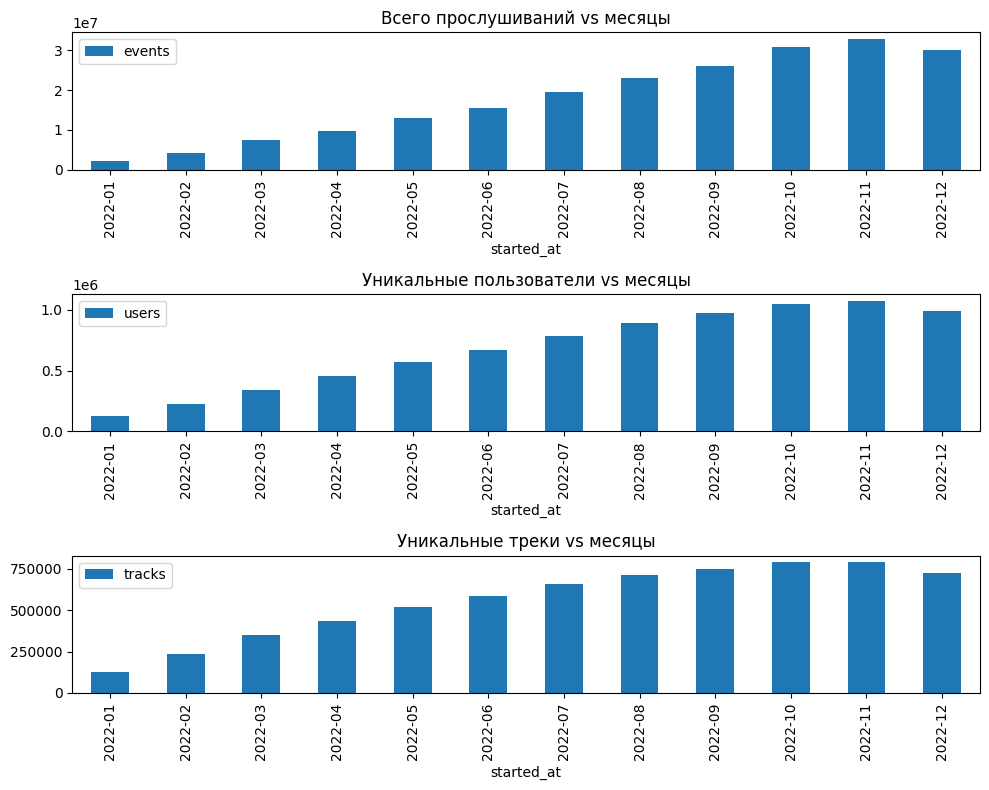

In [3]:
interactions_by_month = interactions.groupby(interactions['started_at'].dt.to_period('M')).agg(events=('started_at', 'count'), users=('user_id', 'nunique'), tracks=('track_id', 'nunique')).reset_index()

fig, ax = plt.subplots(3, 1, figsize=(10, 8))
interactions_by_month.plot('started_at', 'events', kind='bar', title='Всего прослушиваний vs месяцы', ax=ax[0])
interactions_by_month.plot('started_at', 'users', kind='bar', title='Уникальные пользователи vs месяцы', ax=ax[1])
interactions_by_month.plot('started_at', 'tracks', kind='bar', title='Уникальные треки vs месяцы', ax=ax[2])
fig.tight_layout()

interactions_by_month

### Распределение по пользователям
- сколько в среднем пользователь прослушал треков


In [3]:
interactions_by_user = interactions[['track_id', 'user_id']].groupby('user_id').agg(track_count=('track_id', 'count')).sort_values(by='track_count', ascending=False).reset_index()
interactions_by_user

,user_id,track_count
0,398979,16609
1,1200889,14371
2,590868,12700
3,731216,12508
4,339714,12103
...,...,...
1372037,1074759,1
1372038,1026515,1
1372039,489299,1
1372040,1104879,1


In [4]:
# посмотрим квантили распределения 
interactions_by_user['track_count'].describe().astype(int)

# среднее = 156
# min = 1
# 25Q = 22
# медиана = 54
# 75Q = 149
# max = 16609

count    1372042
mean         156
std          335
min            1
25%           22
50%           54
75%          149
max        16609
Name: track_count, dtype: int64

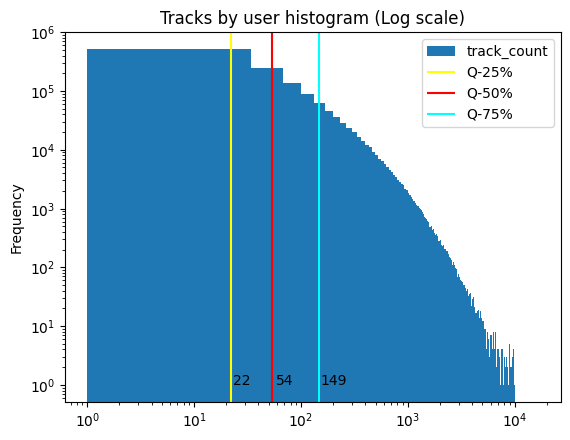

In [ ]:
import numpy as np 

ax = interactions_by_user['track_count'].plot.hist(loglog=True, bins=500, legend=True, title='Tracks by user histogram (Log scale)')
plt.vlines([22], colors='yellow', ymin=0, ymax=1e6, label='Q-25%', )
plt.text(22 + 1, 1, '22')
plt.vlines([54], colors='red', ymin=0, ymax=1e6, label='Q-50%')
plt.text(54 + 5, 1, '54')
plt.vlines([149], colors='cyan', ymin=0, ymax=1e6, label='Q-75%')
plt.text(149 + 5, 1, '149')

ax.legend()

### Распеделение по жанрам

In [31]:
interactions_by_genre = pd.DataFrame(interactions['track_id'].value_counts().sort_values(ascending=False).reset_index()).set_index('track_id') \
    .merge(
        tracks_flat_combined.set_index('track_id')[['genre_name']],
        on='track_id',
        how='left'
    ) \
    .reset_index() \
    .explode('genre_name')  \
    .groupby('genre_name').agg(total_count=('count', 'sum')).sort_values(by='total_count', ascending=False) \
    .reset_index()

interactions_by_genre

,genre_name,total_count
0,pop,55551134
1,rap,37799684
2,allrock,31085569
3,ruspop,26626234
4,rusrap,25303695
...,...,...
126,arts,204
127,news,166
128,society,120
129,religion,73


<Axes: title={'center': 'Intereactions by genre ditribution (Log scale)'}, xlabel='index,genre_name'>

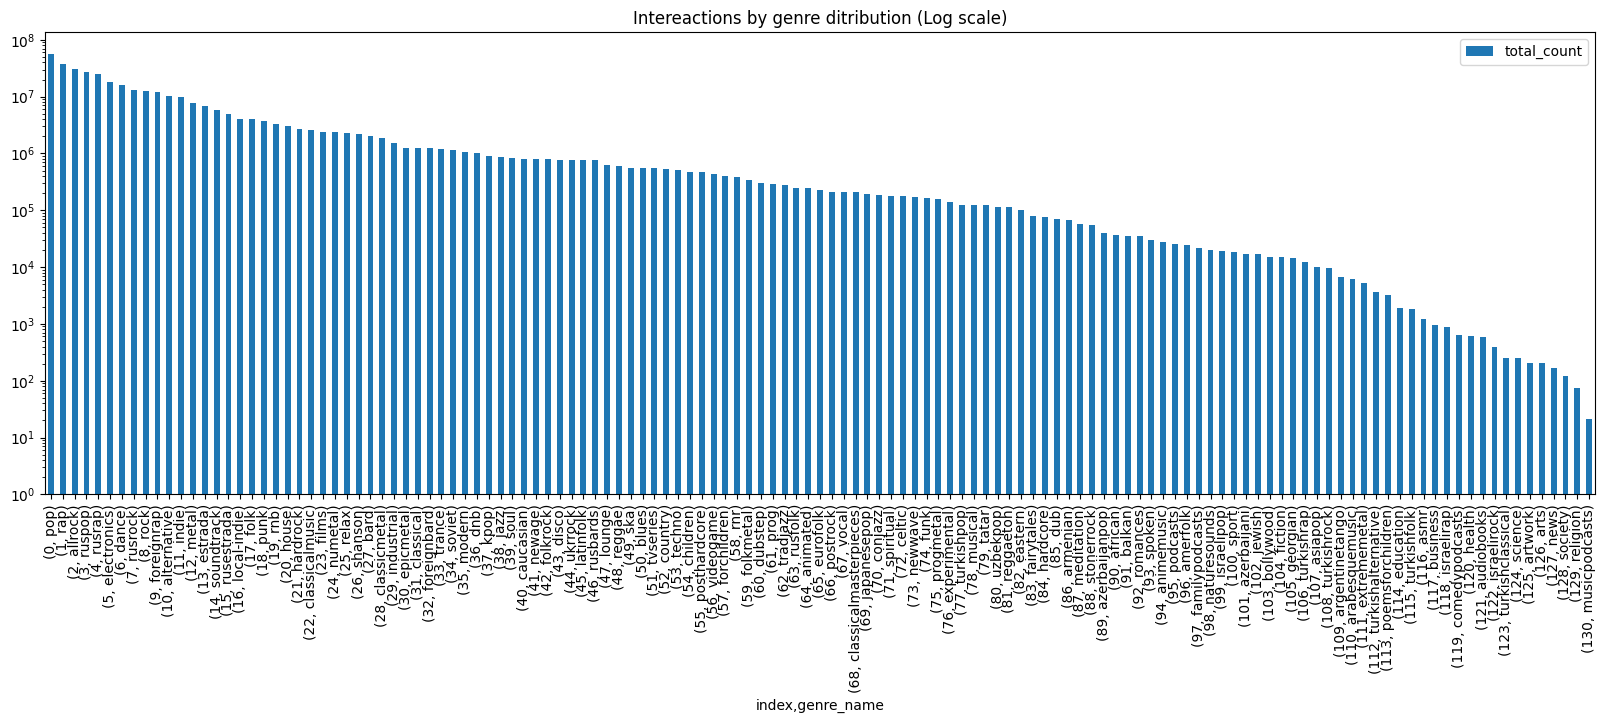

In [63]:
interactions_by_genre \
    .reset_index() \
    .set_index(['index', 'genre_name']) \
    .plot.bar(log=True, legend=True, title='Intereactions by genre ditribution (Log scale)', figsize=(20,6))


### Выводы
- количество пользователей и треков возрастают со временем, сервис набирает популярность, в декабре наметился небольшой спад
- распределение количества прослушанных треков пользователем
    - среднее = 156
    - медиана = 54
    - мин = 1
    - макс = 16609
    - после Q75% = 149 треков количество пользователей логарифмически убывает, и количество треков логарифмически растет
- распределение по жанрам логарифмически по популярности - самые популярные на 6 порядков популярнее (от 55.551.134 до 20 прослушиваний)

## Наиболее популярные треки

- популярность определяем по частности взаимодействия (поскольку данных о рейтингах нет)

In [42]:
tracks_polularity = pd.DataFrame(interactions['track_id'].value_counts().sort_values(ascending=False).reset_index()).set_index('track_id') \
    .merge(
        tracks_flat_combined.set_index('track_id'),
        on='track_id',
        how='left'
    ) \
    .reset_index()

tracks_polularity

,track_id,count,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,53404,111062,Smells Like Teen Spirit,"[4367, 89708, 294911, 294912, 294914, 297393, ...",[9262],"[13, 14, 102]","[Nevermind, Nirvana, Skiing Music, Smells Like...",[Nirvana],"[alternative, rock, allrock]"
1,33311009,106921,Believer,"[4440454, 4456609, 4482682, 4882996, 5072976, ...",[675068],"[14, 102]","[Shape Of Pop, NOW That's What I Call Music, E...",[Imagine Dragons],"[rock, allrock]"
2,178529,101924,Numb,"[18113, 21924, 21940, 488052, 10009799]",[36800],"[41, 47]","[Meteora, 00s Rock Anthems]",[Linkin Park],"[numetal, metal]"
3,35505245,99490,I Got Love,"[4431303, 20559909]","[4611844, 588511]","[3, 75]",[I Got Love],"[Miyagi & Эндшпиль, Рем Дигга]","[rusrap, rap]"
4,65851540,86670,Юность,[10692414],[1554548],"[11, 20]",[Юность],[Dabro],"[pop, ruspop]"
...,...,...,...,...,...,...,...,...,...
932659,22908851,5,Ирина и Марина,[2633273],"[3652834, 3652835]",[50],[Акустика],"[Константин Ступин, Ночная трость]",[punk]
932660,26554967,5,"Верка, Надька и Любка",[3162278],[42581],"[2, 102]",[IV],[Александр Башлачёв],"[rusrock, allrock]"
932661,28518742,5,На всём белом свете,[3412070],[503239],"[2, 102]",[Люди с чистой совестью],[Красные Звёзды],"[rusrock, allrock]"
932662,32507842,5,Солнцеворот,[3962826],[4747339],"[2, 102]",[Жёлтые песни],[Владимир Бурдин],"[rusrock, allrock]"


In [43]:
tracks_polularity[['count']].describe().astype(int)

,count
count,932664
mean,230
std,1404
min,5
25%,9
50%,19
75%,69
max,111062


### График топ-100 треков

<Axes: title={'center': 'Tracks poularity'}, xlabel='index,track_name'>

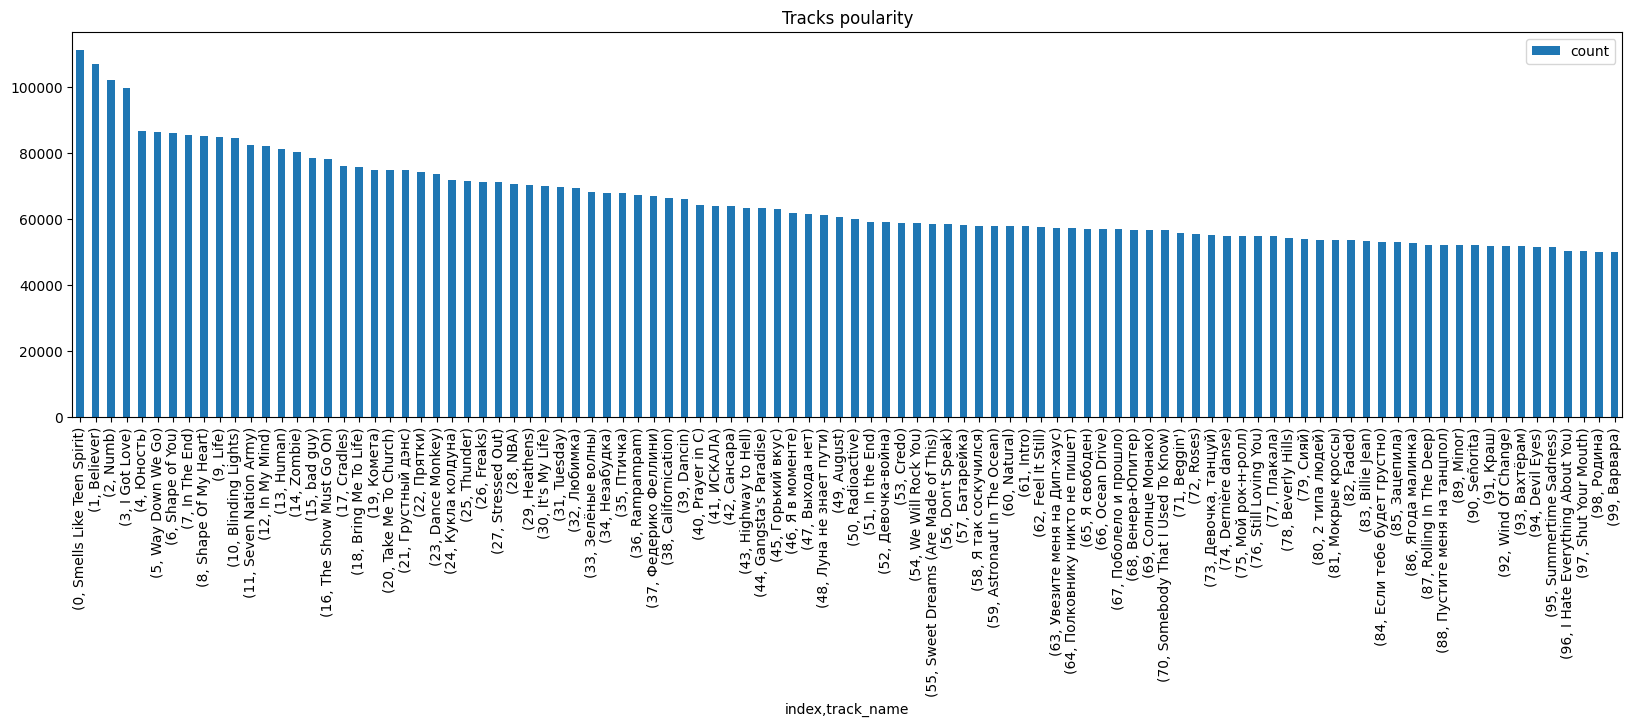

In [65]:
tracks_polularity[['track_name', 'count']] \
    .head(100) \
    .reset_index() \
    .set_index(['index', 'track_name']) \
    .plot.bar(legend=True, title='Tracks poularity', figsize=(20,5))

### Сохраним в файл

In [50]:
# сохраним в файл
data_path = 'data/preprocess/'
tracks_polularity.to_parquet(data_path + "tracks_polularity.parquet")

### Выводы
- популярность треков убывает линейным образом от лидеров к менее популярным
    - среднее - 230
    - мин - 5
    - медиана - 19
    - макс - 111062

## Наиболее популярные жанры

#### Общий список жанров

In [51]:
# список жанров из каталога
genres = catalog.query('type == "genre"').reset_index(drop=True)
genres

,id,type,name
0,0,genre,all
1,1,genre,eastern
2,2,genre,rusrock
3,3,genre,rusrap
4,4,genre,postrock
...,...,...,...
161,1182,genre,balkan
162,1197,genre,experimental
163,1370,genre,europop
164,1484,genre,meditation


In [52]:
# сохраним в файл на будущее
data_path = 'data/preprocess/'
genres.to_parquet(data_path + "genres.parquet")

#### Популярность жанров по истории взаимодействия
- будем определять популярность жанров, исходя из взаимодействий с треками - наиболее часто встречающиеся жанры по всем взаимодействиям со всеми треками (а не топ-треков)

In [ ]:
genres_popularity = pd.DataFrame(interactions['track_id'].value_counts().sort_values(ascending=False).reset_index()) \
    .merge(
        tracks_flat_combined.set_index('track_id')[['genre_id', 'genre_name']],
        on='track_id',
        how='left'
    ) \
    .explode(['genre_id', 'genre_name'])  \
    .groupby(['genre_id', 'genre_name']).agg(count=('count', 'sum')).sort_values(by='count', ascending=False) \
    .reset_index()       

genres_popularity

,genre_id,genre_name,count
0,11,pop,55551134
1,75,rap,37799684
2,102,allrock,31085569
3,20,ruspop,26626234
4,3,rusrap,25303695
...,...,...,...
126,123,artwork,204
127,85,news,166
128,90,society,120
129,87,religion,73


In [ ]:
# сохраним в файл
data_path = 'data/preprocess/'
genres_popularity['genre_id'] = genres_popularity['genre_id'].astype('int')
genres_popularity.to_parquet(data_path + "genres_popularity.parquet")

##### График популярности жанров

<Axes: title={'center': 'Genres popularity (logscale)'}, xlabel='index,genre_name'>

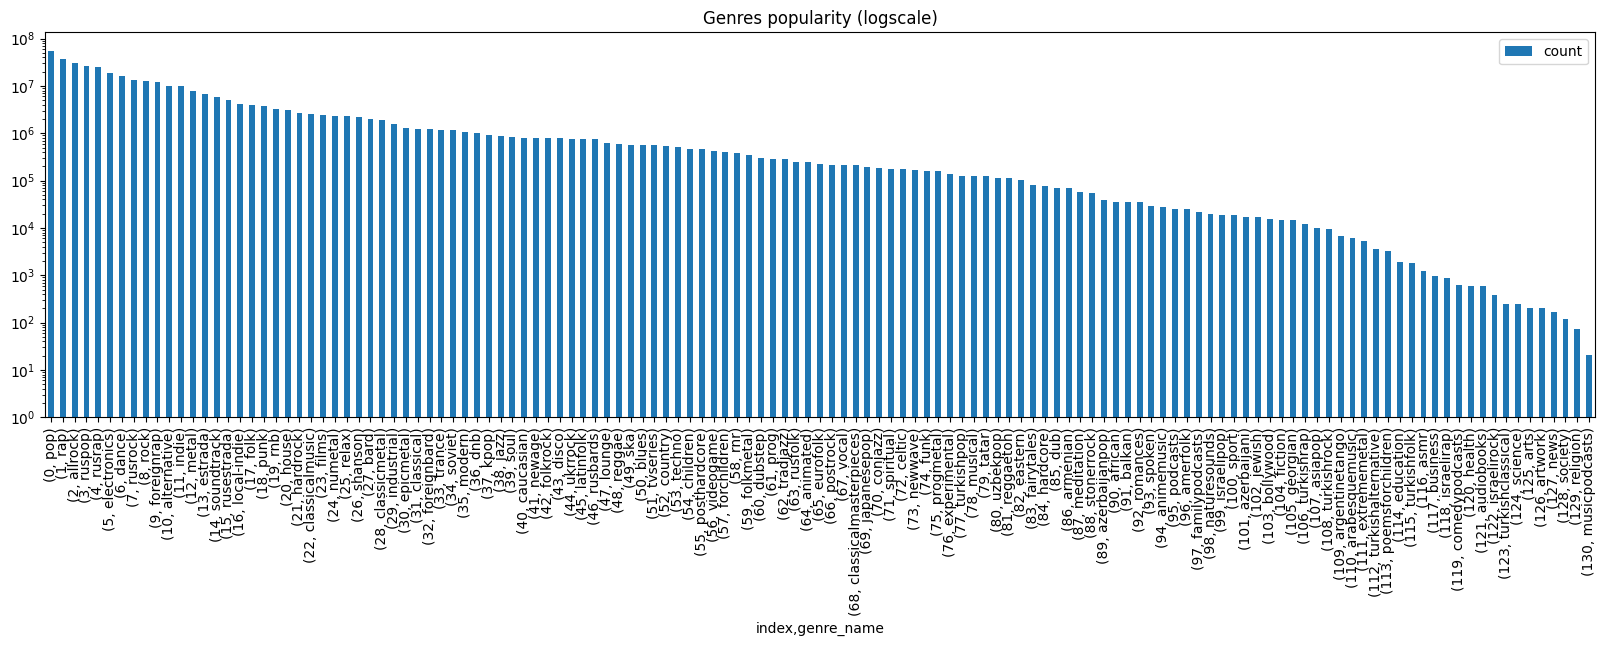

In [87]:
genres_popularity.reset_index()[['index', 'genre_name', 'count']].set_index(['index', 'genre_name']) \
    .plot.bar(log=True, title='Genres popularity (logscale)', figsize=(20,5))

### Непопулярные жанры
Рассмотрим жанры, которые вообще не попали в активность - то есть "непопулярны"

In [97]:
genres_not_popular = genres[~genres['id'].isin(genres_popularity['genre_id'])].reindex().reset_index(drop=True)
print(f'genres not popular (not in history) count = {genres_not_popular.shape[0]}')

genres_not_popular

genres not popular (not in history) count = 35


,id,type,name
0,0,genre,all
1,34,genre,caribbean
2,36,genre,classic
3,42,genre,holiday
4,46,genre,latin
5,78,genre,hobbies
6,81,genre,technology
7,82,genre,government
8,83,genre,historypodcasts
9,91,genre,recreation


In [98]:
tracks_flat_combined[tracks_flat_combined['genre_id'].isin(genres_not_popular['id'])]

,track_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name


### Вывод 
- топ-3 жанра
    - pop
    - rap
    - allrock
- видно что есть 35 жанров, по которым нет истории взаимодействия
    - но и треков с этими жанрами нет

## Треки, которые никто не прослушал

In [100]:
tracks_no_activity = tracks_flat_combined[~tracks_flat_combined['track_id'].isin(tracks_polularity['track_id'])]
tracks_no_activity

,track_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name


### Выводы
- треков, которые никто не прослушал, нет

# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [ ]:
# дополнительных преобразований пока не требуется 
# - tracks_flat_combined - содержит всю необходимую информацию в удобном виде
#   TODO: - возможно придется вернуться сюда на этапе проектирования рекомендательной системы
tracks_flat_combined

,track_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,26,Complimentary Me,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
1,38,Momma's Boy,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
2,135,Atticus,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
3,136,24 Hours,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
4,138,Don't Upset The Rhythm (Go Baby Go),"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],"[Wild Young Hearts, Don't Upset The Rhythm, Hi...",[Noisettes],[pop]
...,...,...,...,...,...,...,...,...
932659,101478482,На лицо,[21399811],[5540395],"[3, 75]",[На лицо],[FLESH],"[rusrap, rap]"
932660,101490148,Без капли мысли,[21403052],[9078726],"[11, 20]",[Без капли мысли],[Даня Милохин],"[pop, ruspop]"
932661,101493057,SKITTLES,[21403883],[11865715],"[44, 75]",[SKITTLES],[WhyBaby?],"[foreignrap, rap]"
932662,101495927,Москва,[21404975],[4462686],"[3, 75]",[Москва],[Yanix],"[rusrap, rap]"


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [102]:
# сначала сохраним локально 
path = 'data/recsys/'

tracks_flat_combined.sort_values(by='track_id', ignore_index=True).to_parquet(path + "items.parquet")
interactions.sort_values(by=['user_id','started_at'], ignore_index=True).to_parquet(path + "events.parquet")


In [103]:
# проверка файлов для отправки в S3

import pandas as pd

path = 'data/recsys/'
items = pd.read_parquet(path + "items.parquet")
events = pd.read_parquet(path + "events.parquet")

Сохранение в S3-хранилище

In [104]:
import os
from dotenv import load_dotenv
load_dotenv()

# pip install s3fs

# теперь сохраним в S3

s3_storage = os.getenv('S3_ENDPOINT_URL')           # https://storage.yandexcloud.net
s3_bucket = os.getenv('S3_BUCKET_NAME')             # s3-student-mle-20260306-f5465b0629-freetrack/Sprint-4
s3_access_key = os.getenv('AWS_ACCESS_KEY_ID')      # YCAJE3Nlz8iDILW5VTYM1ihQB
s3_secret_key = os.getenv('AWS_SECRET_ACCESS_KEY')  # secret

path = "s3://" + s3_bucket + "/recsys/data/"
print(path)

# параметры подключения к S3 хранилищу
storage_options = {
    "client_kwargs": {"endpoint_url": s3_storage},
    "key": s3_access_key,  
    "secret": s3_secret_key,  
}

items.to_parquet(path + "items.parquet", storage_options=storage_options)
events.to_parquet(path + "events.parquet", storage_options=storage_options)

s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-4/recsys/data/


# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [105]:
# 1 - промежуточные файлы сохранены в data/preprocess 
#   - так что для EDA-анализа по этапу 2 можно загрузить файлы в начале секции "Этапа 2" 
#   - и повторить любой из этапов без необходимости выполнения исходной последовательности

# 2 - все рабочие файлы для создания рекомендательной системы сохранены в 
#   - локально - data/recsys 
#   - в S3 - https://storage.yandexcloud.net/s3-student-mle-20260306-f5465b0629-freetrack/Sprint-4/recsys/data/

# - Этап 3 надо начинать с чистого листа и kerner restart

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [1]:
# проверка файлов для отправки в S3

import pandas as pd

path = 'data/recsys/'

#items = pd.read_parquet(path + "items.parquet")
#events = pd.read_parquet(path + "events.parquet")

#--- т.к. даже 32 Gb памяти на ВМ не хватает для полного прогона формирования персональных ALS рекомендаций, то потребуется начинать с промежутончых этапов

# промежуточные результаты, для выполнения разных этапов подготовки - нужно раскрыть нужные комментарии для точечных задач
events_train = pd.read_parquet(path + 'events_train.parquet')


In [3]:
items

,track_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,26,Complimentary Me,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
1,38,Momma's Boy,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
2,135,Atticus,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
3,136,24 Hours,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
4,138,Don't Upset The Rhythm (Go Baby Go),"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],"[Wild Young Hearts, Don't Upset The Rhythm, Hi...",[Noisettes],[pop]
...,...,...,...,...,...,...,...,...
932659,101478482,На лицо,[21399811],[5540395],"[3, 75]",[На лицо],[FLESH],"[rusrap, rap]"
932660,101490148,Без капли мысли,[21403052],[9078726],"[11, 20]",[Без капли мысли],[Даня Милохин],"[pop, ruspop]"
932661,101493057,SKITTLES,[21403883],[11865715],"[44, 75]",[SKITTLES],[WhyBaby?],"[foreignrap, rap]"
932662,101495927,Москва,[21404975],[4462686],"[3, 75]",[Москва],[Yanix],"[rusrap, rap]"


In [2]:
events

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22
...,...,...,...,...
214720733,1374582,95514767,288,2022-12-29
214720734,1374582,97220301,289,2022-12-29
214720735,1374582,97241171,290,2022-12-29
214720736,1374582,98542641,291,2022-12-29


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [27]:
train_date_split = '2022-12-16'
events_train = events.query('started_at < @train_date_split')
events_test = events.query('started_at >= @train_date_split')

print(f'events_train size: {events_train.shape[0]:,} ({(100*events_train.shape[0]/events.shape[0]):.2f}%), events_test size: {events_test.shape[0]:,} ({(100*events_test.shape[0]/events.shape[0]):.2f}%)')

events_train size: 201,204,460 (93.71%), events_test size: 13,516,278 (6.29%)


# Топ популярных

Рассчитаем рекомендации как топ популярных, рассчитанных на этапе 2 EDA - "Наиболее популярные треки" и сохраненные в соответсвующий файл

In [29]:
import pandas as pd

path = 'data/preprocess/'
tracks_polularity = pd.read_parquet(path + "tracks_polularity.parquet")
tracks_polularity

,track_id,count,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,53404,111062,Smells Like Teen Spirit,"[4367, 89708, 294911, 294912, 294914, 297393, ...",[9262],"[13, 14, 102]","[Nevermind, Nirvana, Skiing Music, Smells Like...",[Nirvana],"[alternative, rock, allrock]"
1,33311009,106921,Believer,"[4440454, 4456609, 4482682, 4882996, 5072976, ...",[675068],"[14, 102]","[Shape Of Pop, NOW That's What I Call Music, E...",[Imagine Dragons],"[rock, allrock]"
2,178529,101924,Numb,"[18113, 21924, 21940, 488052, 10009799]",[36800],"[41, 47]","[Meteora, 00s Rock Anthems]",[Linkin Park],"[numetal, metal]"
3,35505245,99490,I Got Love,"[4431303, 20559909]","[4611844, 588511]","[3, 75]",[I Got Love],"[Miyagi & Эндшпиль, Рем Дигга]","[rusrap, rap]"
4,65851540,86670,Юность,[10692414],[1554548],"[11, 20]",[Юность],[Dabro],"[pop, ruspop]"
...,...,...,...,...,...,...,...,...,...
932659,22908851,5,Ирина и Марина,[2633273],"[3652834, 3652835]",[50],[Акустика],"[Константин Ступин, Ночная трость]",[punk]
932660,26554967,5,"Верка, Надька и Любка",[3162278],[42581],"[2, 102]",[IV],[Александр Башлачёв],"[rusrock, allrock]"
932661,28518742,5,На всём белом свете,[3412070],[503239],"[2, 102]",[Люди с чистой совестью],[Красные Звёзды],"[rusrock, allrock]"
932662,32507842,5,Солнцеворот,[3962826],[4747339],"[2, 102]",[Жёлтые песни],[Владимир Бурдин],"[rusrock, allrock]"


## Сохраним топ-100 треков в top_popular.parquet

In [30]:
path = 'data/recsys/'
top_n = 100
tracks_polularity.head(top_n).to_parquet(path + 'top_popular.parquet')

# Персональные

Рассчитаем персональные рекомендации.

## Закодируем идентификторы объектов для подготовки csr-матрицы

In [32]:
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
user_encoder.fit(events.user_id)

item_encoder = LabelEncoder()
item_encoder.fit(events.track_id)

LabelEncoder()

Сохраним кодировщики в файл, для будущего переиспользования и экономии памяти на последующих этапах

In [34]:
import joblib

path = 'data/recsys/'
joblib.dump(user_encoder, path + 'user_encoder.joblib')
joblib.dump(item_encoder, path + 'item_encoder.joblib')

['data/recsys/item_encoder.joblib']

Загрузка из файлов при необходимости на нужном этапе

In [6]:
import joblib

path = 'data/recsys/'
user_encoder = joblib.load(path + 'user_encoder.joblib')
item_encoder = joblib.load(path + 'item_encoder.joblib')

In [36]:
events_train['user_id_enc'] = user_encoder.transform(events_train.user_id)
events_train['track_id_enc'] = item_encoder.transform(events_train.track_id)

/tmp/ipykernel_2028/4131578047.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_train['user_id_enc'] = user_encoder.transform(events_train.user_id)
/tmp/ipykernel_2028/4131578047.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_train['track_id_enc'] = item_encoder.transform(events_train.track_id)


Выполним промежуточное сохранение events_train с закодированными идентификаторами в файл

In [ ]:
path = 'data/recsys/'
events_train.to_parquet(path + 'events_train.parquet')

## Сформируем матрицу взаимодействия user-2-item

In [5]:
from scipy.sparse import csr_matrix
import numpy as np

user2item_matrix_train = csr_matrix(
    (np.ones(events_train.shape[0], dtype=np.int8),
    (events_train.user_id_enc.values, events_train.track_id_enc.values))
)
user2item_matrix_train

<Compressed Sparse Row sparse matrix of dtype 'int8'
	with 201204460 stored elements and shape (1372042, 932664)>

## Обучим ALS-модель

In [6]:
%env OPENBLAS_NUM_THREADS=1

from implicit.als import AlternatingLeastSquares

n_factors = 50
n_iterations=15
model_als = AlternatingLeastSquares(factors=n_factors, iterations=n_iterations, regularization=0.05, random_state=15)
model_als.fit(user2item_matrix_train)

env: OPENBLAS_NUM_THREADS=1


/home/mle-user/mle_projects/sprint-4/mle-project-sprint-4-v001/.venv_mle-project-sprint-4-v001/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 15/15 [12:26<00:00, 49.78s/it]


### Сохраним обученную модель в файл
- сэкономим 12 минут при повторных операциях

In [7]:
path = 'data/recsys/'
model_als.save(path + 'model_als_trained.npz')

### Загрузим обученную модель из файла 
- точнее обученные параметры

In [ ]:
path = 'data/recsys/'

n_factors = 50
n_iterations=15
model_als = AlternatingLeastSquares(factors=n_factors, iterations=n_iterations, regularization=0.05, random_state=15)

model_als.load(path + 'model_als_trained.npz')

### Посмотрим как работает ALS-модель на примерах

In [ ]:
#TODO

## Сформируем персональные рекомендации для всех пользователей

In [1]:
# clear as much memory as we can

#del events
#del events_train

In [17]:
# получаем список всех возможных user_id (перекодированных)
user_ids_encoded = range(len(user_encoder.classes_))

# получаем рекомендации для всех пользователей
als_recommendations_raw = model_als.recommend(
    user_ids_encoded, 
    user2item_matrix_train[user_ids_encoded], 
    filter_already_liked_items=False, 
    N=100)

item_ids_enc = als_recommendations_raw[0]
scores_als = als_recommendations_raw[1]

### Сохраним в файл сырые данные рекомендаций

In [ ]:
import numpy as np

path = 'data/recsys/'
np.savez_compressed(path + 'als_recommendations_raw.npz', item_ids=item_ids_enc, scores=scores_als)

### Загрузка готовых сырых рекомендаций из файла

In [ ]:
import numpy as np

path = 'data/recsys/'

loaded_recs = np.load(path + 'als_recommendations_raw.npz')
item_ids_enc = loaded_recs['item_ids']
scores_als = loaded_recs['scores']

## Сформируем рекомендации в удобном табличном формате

In [ ]:
import pandas as pd

# преобразуем полученные рекомендации в табличный формат (~15Gb memory required)

user_ids_encoded = range(len(user_encoder.classes_))

als_recommendations = pd.DataFrame({
    "user_id_enc": user_ids_encoded,
    "item_id_enc": item_ids_enc.tolist(), 
    "score": scores_als.tolist()})
als_recommendations = als_recommendations.explode(["item_id_enc", "score"], ignore_index=True)

# приводим типы данных
als_recommendations["item_id_enc"] = als_recommendations["item_id_enc"].astype("int")
als_recommendations["score"] = als_recommendations["score"].astype("float")

# получаем изначальные идентификаторы
als_recommendations["user_id"] = user_encoder.inverse_transform(als_recommendations["user_id_enc"])
als_recommendations["item_id"] = item_encoder.inverse_transform(als_recommendations["item_id_enc"])
als_recommendations = als_recommendations.drop(columns=["user_id_enc", "item_id_enc"])

als_recommendations

,score,user_id,item_id
0,0.014193,0,597196
1,0.012967,0,29213451
2,0.012012,0,27077792
3,0.010728,0,19722850
4,0.010566,0,21101463
...,...,...,...
137204195,0.095507,1374582,48591588
137204196,0.095246,1374582,33308971
137204197,0.094276,1374582,72340123
137204198,0.094246,1374582,68106316


### Сохраним полученные рекомендации в файл

In [9]:
als_recommendations = als_recommendations[["user_id", "item_id", "score"]]

path = 'data/recsys/'
als_recommendations.to_parquet(path + "personal_als.parquet")

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.